# Gráficos

In [2]:
from benchmark import rosenbrock, sphere, rastrigin, sum_squares, zakharov, levy, schwefel, griewank, ackley, dixon_price
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

def plot_function(
    func,
    x_range,
    y_range,
    levels=50,
    title="Function",
    use_log=False,
    clip_percentile=None,
    grid_size=200,
    view_elev=25,
    view_azim=45,
    cmap="viridis",
):
    """Plot 3D surface and contour for a benchmark function."""
    x = np.linspace(*x_range, grid_size)
    y = np.linspace(*y_range, grid_size)
    X, Y = np.meshgrid(x, y)
    XY = np.column_stack([X.ravel(), Y.ravel()])
    Z = func(XY).reshape(X.shape)

    if clip_percentile is not None:
        # Clip very high values to reveal valleys in highly scaled functions.
        upper = np.percentile(Z, clip_percentile)
        Z = np.clip(Z, None, upper)

    if use_log:
        Z = np.log1p(Z)

    fig = plt.figure(figsize=(14, 5))
    
    # 3D surface
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title(f'{title} - 3D Surface', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('log(1+f)' if use_log else 'f')
    ax1.view_init(elev=view_elev, azim=view_azim)
    surf = ax1.plot_surface(X, Y, Z, cmap=cmap, edgecolor='none', alpha=0.9)
    plt.colorbar(surf, ax=ax1, shrink=0.5)

    # Contour plot
    ax2 = fig.add_subplot(122)
    ax2.set_title(f'{title} - Contour Map', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_aspect('equal')
    contour = ax2.contourf(X, Y, Z, levels=levels, cmap=cmap)
    contour_lines = ax2.contour(X, Y, Z, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    ax2.clabel(contour_lines, inline=True, fontsize=8)
    plt.colorbar(contour, ax=ax2)

    plt.tight_layout()
    plt.show()

## Unimodal


### Rosenbrock

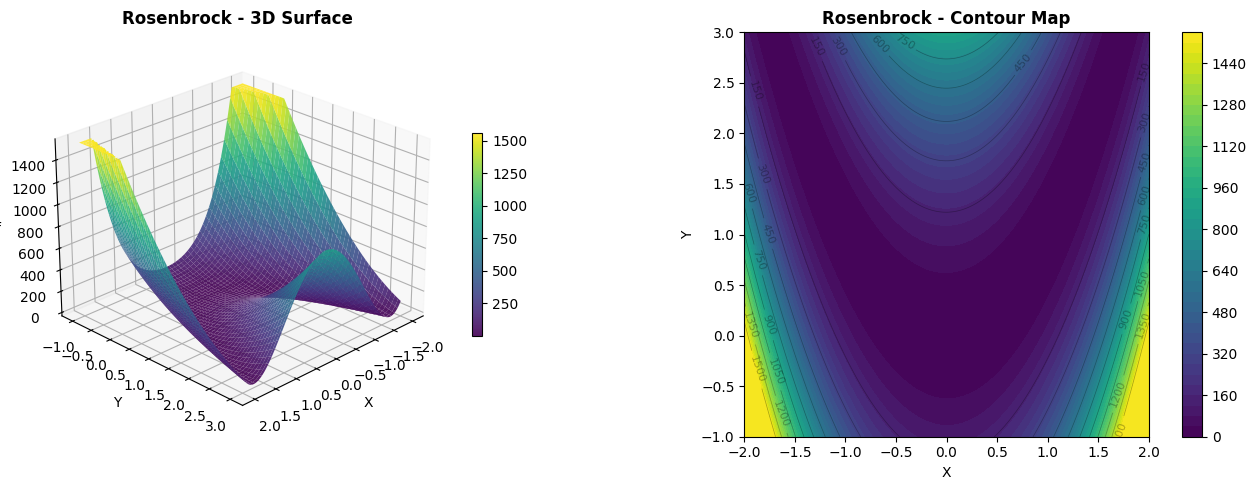

In [3]:
plot_function(
    rosenbrock,
    (-2, 2), (-1, 3),   # domínio canônico
    levels=50,
    title='Rosenbrock',
    clip_percentile=98,  # corta os picos extremos das bordas
)

### Sphere

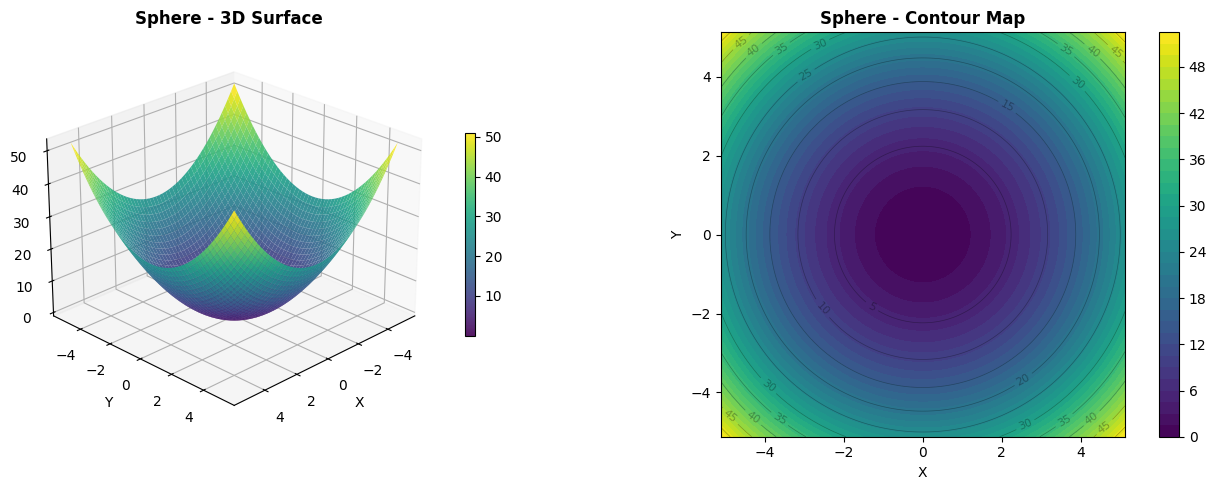

In [4]:
plot_function(sphere, (-5.12, 5.12), (-5.12, 5.12), levels=50, title='Sphere')

### Sum Squares

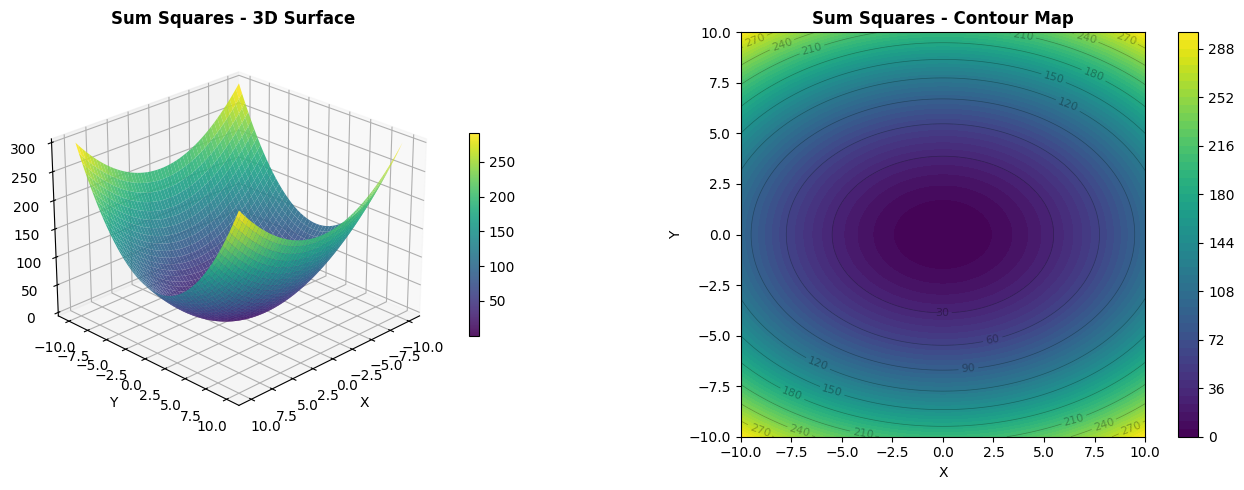

In [5]:
plot_function(sum_squares, (-10, 10), (-10, 10), levels=50, title='Sum Squares')

### Dixon-Price

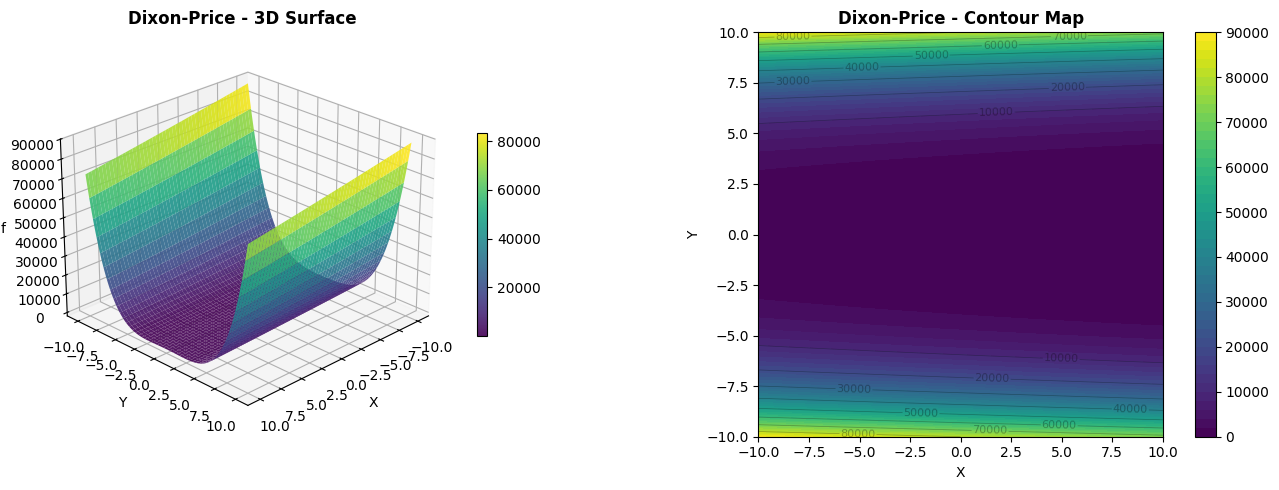

In [6]:
plot_function(dixon_price, (-10, 10), (-10, 10), levels=50, title='Dixon-Price')

### Zakharov

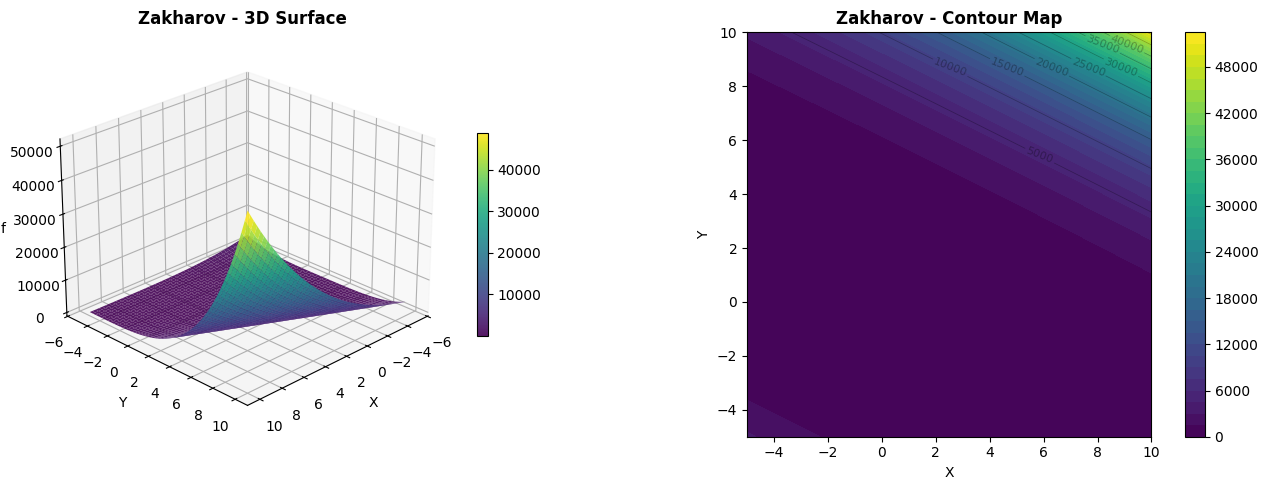

In [7]:
plot_function(zakharov, (-5, 10), (-5, 10), levels=50, title='Zakharov')

## Multimodal


### Rastringin

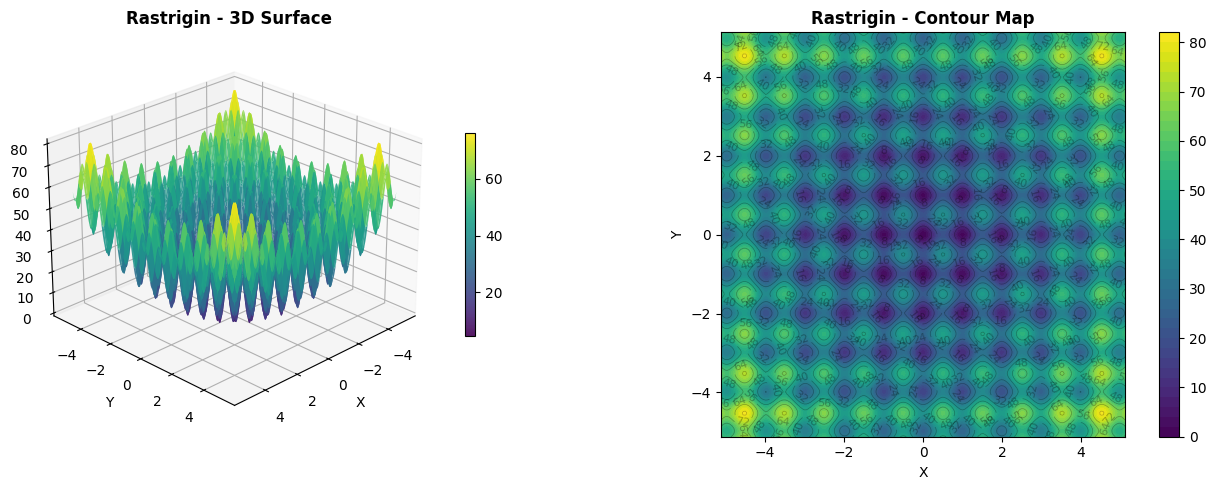

In [8]:
plot_function(rastrigin, (-5.12, 5.12), (-5.12, 5.12), levels=50, title='Rastrigin')

### Ackley

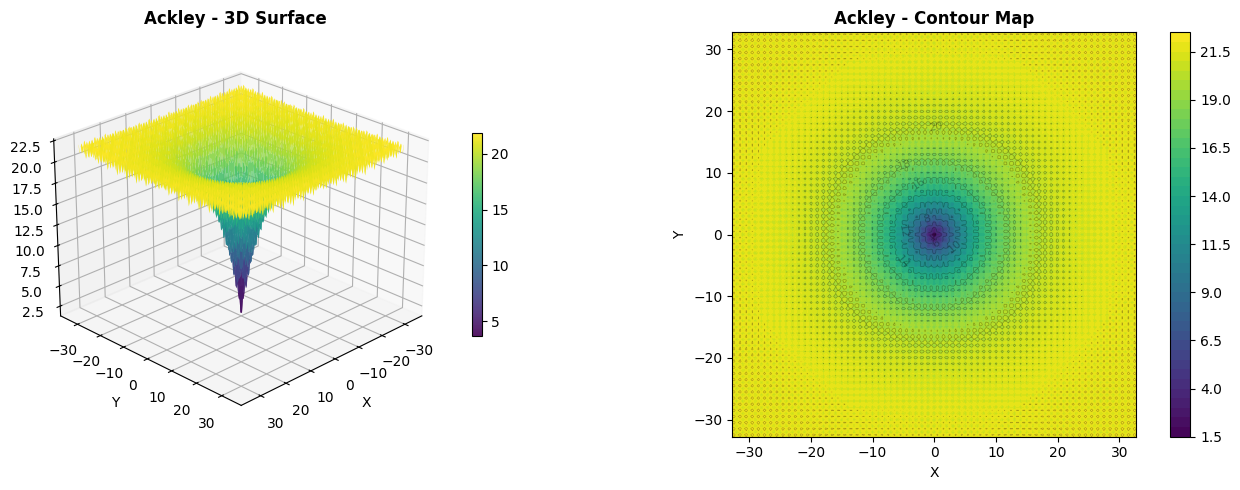

In [9]:
plot_function(ackley, (-32.768, 32.768), (-32.768, 32.768), levels=50, title='Ackley')

### Griewank


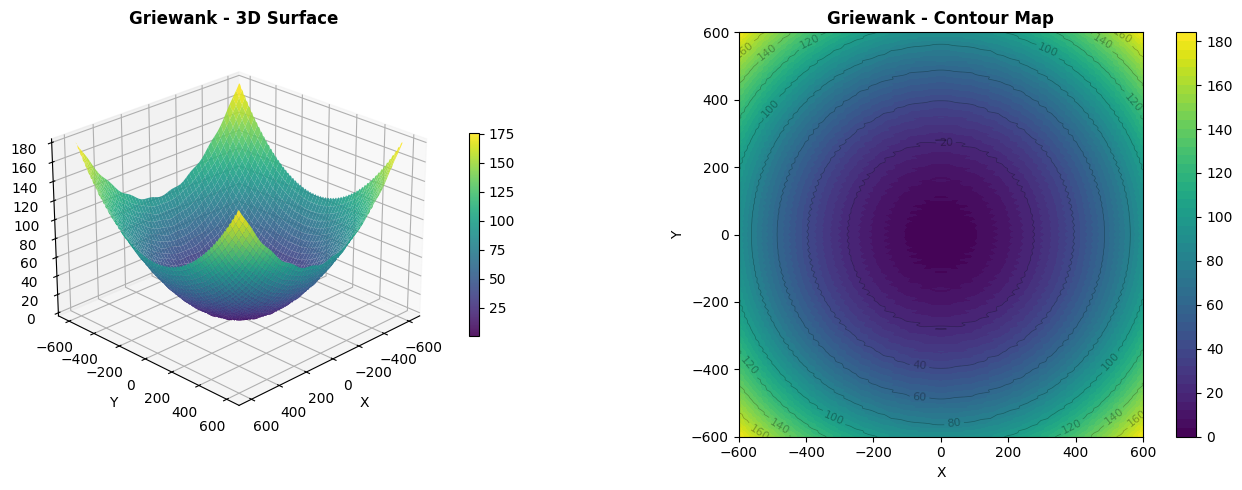

In [10]:
plot_function(griewank, (-600, 600), (-600, 600), levels=50, title='Griewank')

### Schwefel

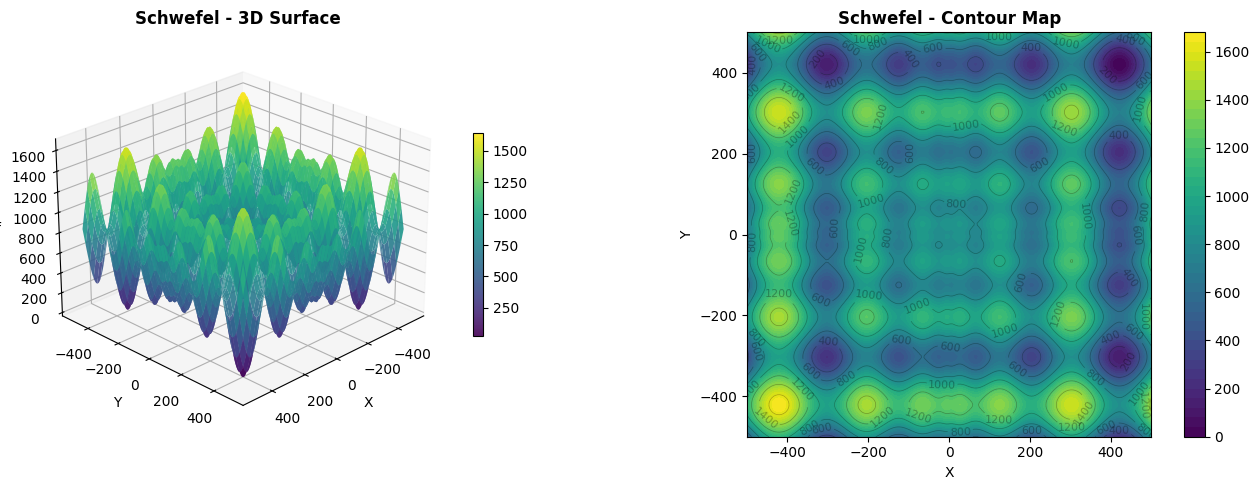

In [11]:
plot_function(schwefel, (-500, 500), (-500, 500), levels=50, title='Schwefel')

### Levy

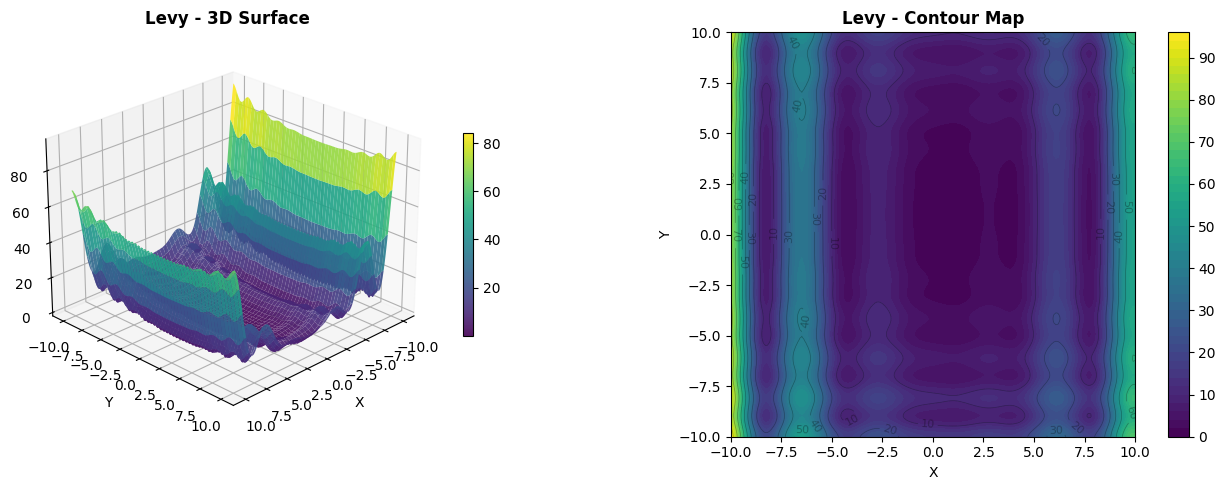

In [12]:
plot_function(levy, (-10, 10), (-10, 10), levels=50, title='Levy')